# Week 6: Behavioral Authentication Defender Pipeline on Balabit
This notebook extends the Week 5 fair baseline comparison with a completed defender-side evaluation: full model tiers, per-user vulnerability forecasting, a post-authentication anomaly detection layer, and SHAP feature explainability. The attacker side (WindMouse, SapiAgent) is being built separately and plugs in via a defined data contract, marked where attack results will be merged.

**Evaluation design:**

Binary authentication: 1 = genuine enrolled user, 0 = imposter

Per-user models: each user is evaluated separately

Window size: 128 time steps

Fair protocol: same users, windows, fit/calibration/test split, seeds, threshold policies, and metrics across tiers

Threshold policies: default 0.5, calibration EER threshold, and calibration low-FAR threshold

**Model tiers:**

*   T0: rule/threshold sanity baseline
*   T1: Logistic Regression, SVM, k-NN, and Decision Tree
*   T2: Random Forest, ExtraTrees, Gradient Boosting, and XGBoost
*   T3: 1D-CNN sequence baseline

**Reported metrics** include TAR, FAR, FRR, F1, AUC, EER, and per-user vulnerability.


**New this week:** vulnerability classification (low/medium/high, cross-validated forecasting model), a robustness-drop metric ready for real attack data, an Isolation Forest anomaly detection layer sitting behind the authentication decision, and SHAP-based feature importance checked across multiple users.


#Setting Up the Environment

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import tensorflow as tf, numpy as np, random;
#print(tf.__version__)
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# Part 1 Get the Data

In [6]:
!git clone https://github.com/balabit/Mouse-Dynamics-Challenge

Cloning into 'Mouse-Dynamics-Challenge'...
remote: Enumerating objects: 1711, done.
remote: Total 1711 (delta 0), reused 0 (delta 0), pack-reused 1711 (from 1)
Receiving objects: 100% (1711/1711), 42.60 MiB | 14.27 MiB/s, done.
Resolving deltas: 100% (3/3), done.


#Part 2 Loading the Data

In [7]:
import pandas as pd

def load_session(path):
  df = pd.read_csv(path, sep=',')
  df = df.sort_values('record timestamp')
  df = df.dropna(subset=['x', 'y'])
  return df

In [8]:
import os

all_sessions = []

training_path = '/content/Mouse-Dynamics-Challenge/training_files'

for user in sorted(os.listdir(training_path)):
    user_path = os.path.join(training_path, user)
    if not os.path.isdir(user_path):
        continue
    for session_file in sorted(os.listdir(user_path)):
        session_path = os.path.join(user_path, session_file)
        df = load_session(session_path)
        df['user'] = user
        df['session'] = session_file
        df['label'] = 0
        all_sessions.append(df)

print(f"Loaded {len(all_sessions)} sessions")

Loaded 65 sessions


In [9]:
# Check which users loaded and how many sessions each has
from collections import Counter
user_counts = Counter(df['user'].iloc[0] for df in all_sessions)
print(user_counts)

Counter({'user12': 7, 'user20': 7, 'user21': 7, 'user29': 7, 'user7': 7, 'user9': 7, 'user15': 6, 'user16': 6, 'user23': 6, 'user35': 5})


In [10]:
import pandas as pd

# Load labels
labels_path = '/content/Mouse-Dynamics-Challenge/public_labels.csv'
labels_df = pd.read_csv(labels_path, sep=',')
print(labels_df.head())
print(labels_df.shape)

             filename  is_illegal
0  session_0003960194           1
1  session_0005840196           0
2  session_0025450757           0
3  session_0029922803           0
4  session_0064281061           1
(816, 2)


In [11]:
test_sessions = []

test_path = '/content/Mouse-Dynamics-Challenge/test_files'

for user in sorted(os.listdir(test_path)):
    user_path = os.path.join(test_path, user)
    if not os.path.isdir(user_path):
        continue
    for session_file in sorted(os.listdir(user_path)):
        session_path = os.path.join(user_path, session_file)

        # look up label from public_labels.csv
        match = labels_df[labels_df['filename'] == session_file]
        if match.empty:
            continue  # skip sessions without a public label

        label = match.iloc[0]['is_illegal']
        df = load_session(session_path)
        df['user'] = user
        df['session'] = session_file
        df['label'] = label
        test_sessions.append(df)

print(f"Loaded {len(test_sessions)} labeled test sessions")

# sanity check label distribution
import collections
label_counts = collections.Counter(df['label'].iloc[0] for df in test_sessions)
print(label_counts)

Loaded 816 labeled test sessions
Counter({np.int64(0): 411, np.int64(1): 405})


#Part 3: Feature Extraction

In [12]:
def extract_features(df):
    df = df.copy().reset_index(drop=True)

    dt = df['record timestamp'].diff().fillna(0)
    dt = dt.replace(0, 1e-6)

    dx = df['x'].diff().fillna(0)
    dy = df['y'].diff().fillna(0)
    dist = np.sqrt(dx**2 + dy**2)
    dist_safe = dist.replace(0, 1e-6)

    vx = dx / dt
    vy = dy / dt
    velocity = dist / dt
    acceleration = velocity.diff().fillna(0) / dt
    jerk = acceleration.diff().fillna(0) / dt
    angle = np.arctan2(dy, dx)
    curvature = angle.diff().fillna(0) / dist_safe
    pause = (dt > 0.1).astype(int)

    result = pd.DataFrame({
        'vx': vx, 'vy': vy, 'velocity': velocity,
        'acceleration': acceleration, 'jerk': jerk,
        'angle': angle, 'curvature': curvature, 'pause': pause
    })

    result = result.replace([np.inf, -np.inf], np.nan).fillna(0)

    # hard absolute caps based on realistic mouse movement
    result['vx'] = result['vx'].clip(-5000, 5000)
    result['vy'] = result['vy'].clip(-5000, 5000)
    result['velocity'] = result['velocity'].clip(0, 5000)
    result['acceleration'] = result['acceleration'].clip(-1e6, 1e6)
    result['jerk'] = result['jerk'].clip(-1e8, 1e8)
    result['curvature'] = result['curvature'].clip(-100, 100)

    return result

sample = extract_features(all_sessions[0])
print(sample.describe())

                 vx            vy      velocity    acceleration          jerk  \
count  30287.000000  30287.000000  30287.000000    30287.000000  3.028700e+04   
mean     -37.606529     -7.044697   1081.951073    -1041.693338  9.372418e+06   
std     1994.003994   1921.288506   1806.426256   544424.122343  6.248204e+07   
min    -5000.000000  -5000.000000      0.000000 -1000000.000000 -1.000000e+08   
25%      -90.378483    -53.097261     16.563467    -2329.218773 -1.448147e+04   
50%        0.000000      0.000000    149.267215       -2.256236  2.623155e+03   
75%       54.545507     41.350804    902.309129     2056.715488  3.965950e+07   
max     5000.000000   5000.000000   5000.000000  1000000.000000  1.000000e+08   

              angle     curvature         pause  
count  30287.000000  30287.000000  30287.000000  
mean       0.109441      0.624497      0.780467  
std        1.823200     18.329134      0.413937  
min       -3.138438   -100.000000      0.000000  
25%       -1.518213 

#Part 4 Windowing, labels, and the splie

In [13]:
WINDOW = 128
FEATURE_COLS = ['vx','vy','velocity','acceleration','jerk','angle','curvature','pause']

def make_windows(session_list):
    X, y = [], []
    for df in session_list:
        feats = extract_features(df).values
        label = df['label'].iloc[0]
        n_windows = len(feats) // WINDOW       # drops leftover partial window
        for w in range(n_windows):
            chunk = feats[w*WINDOW:(w+1)*WINDOW]
            X.append(chunk)
            y.append(label)
    return np.array(X), np.array(y)

# split by session: all_sessions (label 0) + 80% of test_sessions for training
import random
random.seed(42)
shuffled = test_sessions.copy()
random.shuffle(shuffled)
split = int(0.8 * len(shuffled))

train_sessions = all_sessions + shuffled[:split]
val_sessions = shuffled[split:]

X_train, y_train = make_windows(train_sessions)
X_val, y_val = make_windows(val_sessions)

print("Train:", X_train.shape, "labels:", np.bincount(y_train.astype(int)))
print("Val:", X_val.shape, "labels:", np.bincount(y_val.astype(int)))

Train: (24464, 128, 8) labels: [21854  2610]
Val: (1756, 128, 8) labels: [1171  585]


# Fair T0-T3 Baseline Comparison

The models have different complexity by design, but the evaluation protocol is held constant. T3 uses an internal validation split for early stopping so the calibration split remains reserved for threshold selection, matching the role of calibration data in T0/T1/T2.


In [14]:
from IPython.display import display
import random as pyrandom
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, roc_curve

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBClassifier = None
    XGBOOST_AVAILABLE = False

FAIR_SEEDS = [0, 1, 2]
CALIBRATION_SIZE = 0.25
T3_VALIDATION_SIZE = 0.20
LOW_FAR_TARGET = 0.10
T3_EPOCHS = 20
T3_BATCH_SIZE = 64
summary_cols = ["TAR", "FAR", "FRR", "F1", "AUC", "EER"]


def windows_from_sessions(session_list, label):
    X = []
    for df in session_list:
        feats = extract_features(df).values
        n = len(feats) // WINDOW
        for w in range(n):
            X.append(feats[w*WINDOW:(w+1)*WINDOW])
    return np.array(X), np.full(len(X), label, dtype=int)


def get_user(df):
    return df['user'].iloc[0]


def get_label(df):
    return df['label'].iloc[0]


def summarize_window(window):
    window = np.asarray(window, dtype=float)
    row = {}
    for j, name in enumerate(FEATURE_COLS):
        values = window[:, j]
        values = values[np.isfinite(values)]
        if len(values) == 0:
            values = np.array([0.0])
        row[f"{name}_mean"] = float(np.mean(values))
        row[f"{name}_std"] = float(np.std(values))
        row[f"{name}_median"] = float(np.median(values))
        row[f"{name}_min"] = float(np.min(values))
        row[f"{name}_max"] = float(np.max(values))
        row[f"{name}_p25"] = float(np.percentile(values, 25))
        row[f"{name}_p75"] = float(np.percentile(values, 75))
        row[f"{name}_p90"] = float(np.percentile(values, 90))
    speed = window[:, FEATURE_COLS.index("velocity")]
    pause = window[:, FEATURE_COLS.index("pause")]
    row["path_length_approx"] = float(np.sum(np.maximum(speed, 0)))
    row["pause_rate"] = float(np.mean(pause > 0))
    row["duration_windows"] = float(window.shape[0])
    return row


def windows_to_tabular(X_windows):
    rows = [summarize_window(w) for w in X_windows]
    return pd.DataFrame(rows).replace([np.inf, -np.inf], np.nan).fillna(0.0)


def compute_eer_threshold(y_true, scores):
    if len(np.unique(y_true)) < 2:
        return np.nan, 0.5
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fpr - fnr))
    return float((fpr[idx] + fnr[idx]) / 2), float(thresholds[idx])


def threshold_for_target_far(y_true, scores, target_far=LOW_FAR_TARGET):
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores, dtype=float)
    candidate_thresholds = np.r_[np.unique(scores), 1.0 + 1e-9]
    best_threshold, best_tar, best_far = 1.0 + 1e-9, -1.0, 0.0
    for threshold in candidate_thresholds:
        y_pred = (scores >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        tar = tp / (tp + fn) if (tp + fn) else 0.0
        far = fp / (fp + tn) if (fp + tn) else 0.0
        if far <= target_far and tar > best_tar:
            best_threshold, best_tar, best_far = float(threshold), float(tar), float(far)
    return best_threshold, best_far, best_tar


def evaluate_auth_scores(y_true, scores, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores, dtype=float)
    y_pred = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    tar = tp / (tp + fn) if (tp + fn) else 0.0
    far = fp / (fp + tn) if (fp + tn) else 0.0
    frr = fn / (tp + fn) if (tp + fn) else 0.0
    auc = roc_auc_score(y_true, scores) if len(np.unique(y_true)) > 1 else np.nan
    eer, eer_threshold = compute_eer_threshold(y_true, scores)
    return {
        "TAR": tar,
        "FAR": far,
        "FRR": frr,
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "AUC": auc,
        "EER": eer,
        "test_EER_threshold": eer_threshold,
        "decision_threshold": float(threshold),
    }


def threshold_policy_rows(user, tier, model_name, y_cal, cal_scores, y_test, test_scores, seed):
    cal_eer, cal_eer_threshold = compute_eer_threshold(y_cal, cal_scores)
    low_far_threshold, cal_far_at_low_far, cal_tar_at_low_far = threshold_for_target_far(
        y_cal, cal_scores, target_far=LOW_FAR_TARGET
    )
    threshold_policies = [
        ("default_0.5", 0.5, np.nan, np.nan, np.nan),
        ("calibration_EER", cal_eer_threshold, cal_eer, np.nan, np.nan),
        (f"calibration_FAR<={LOW_FAR_TARGET:.2f}", low_far_threshold, np.nan, cal_far_at_low_far, cal_tar_at_low_far),
    ]
    rows = []
    for policy_name, threshold, cal_eer_value, cal_far_value, cal_tar_value in threshold_policies:
        metrics = evaluate_auth_scores(y_test, test_scores, threshold=threshold)
        metrics.update({
            "user": user,
            "tier": tier,
            "model": model_name,
            "threshold_policy": policy_name,
            "calibration_EER": cal_eer_value,
            "calibration_FAR_at_threshold": cal_far_value,
            "calibration_TAR_at_threshold": cal_tar_value,
            "seed": seed,
        })
        rows.append(metrics)
    return rows


## Shared Per-User Split

Every tier uses this same split function. Training imposters are sampled from other users, then the training set is split into fit and calibration subsets.


In [15]:
def get_fair_user_splits(target, seed=42, balance_imposters=True):
    rng = np.random.default_rng(seed)
    gen_train = [s for s in all_sessions if get_user(s) == target]
    imp_train = [s for s in all_sessions if get_user(s) != target]
    Xg, yg = windows_from_sessions(gen_train, 1)
    Xi, yi = windows_from_sessions(imp_train, 0)
    if balance_imposters and len(Xi) > len(Xg):
        idx = rng.choice(len(Xi), size=len(Xg), replace=False)
        Xi, yi = Xi[idx], yi[idx]
    X_train_seq = np.concatenate([Xg, Xi])
    y_train = np.concatenate([yg, yi])
    train_idx = np.arange(len(y_train))
    fit_idx, cal_idx = train_test_split(
        train_idx,
        test_size=CALIBRATION_SIZE,
        stratify=y_train,
        random_state=seed,
    )
    gen_test = [s for s in test_sessions if get_user(s) == target and get_label(s) == 0]
    imp_test = [s for s in test_sessions if get_user(s) == target and get_label(s) == 1]
    Xtg, ytg = windows_from_sessions(gen_test, 1)
    Xti, yti = windows_from_sessions(imp_test, 0)
    X_test_seq = np.concatenate([Xtg, Xti])
    y_test = np.concatenate([ytg, yti])
    X_train_tab = windows_to_tabular(X_train_seq)
    X_test_tab = windows_to_tabular(X_test_seq)
    return {
        "X_fit_seq": X_train_seq[fit_idx],
        "X_cal_seq": X_train_seq[cal_idx],
        "X_test_seq": X_test_seq,
        "X_fit_tab": X_train_tab.iloc[fit_idx].reset_index(drop=True),
        "X_cal_tab": X_train_tab.iloc[cal_idx].reset_index(drop=True),
        "X_test_tab": X_test_tab.reset_index(drop=True),
        "y_fit": y_train[fit_idx],
        "y_cal": y_train[cal_idx],
        "y_test": y_test,
    }


# T0 Rule/Threshold Baseline


In [16]:
def t0_distance_profile_scores(X_fit, y_fit, X_eval):
    scaler = StandardScaler().fit(X_fit)
    X_fit_s = scaler.transform(X_fit)
    X_eval_s = scaler.transform(X_eval)
    center = np.median(X_fit_s[y_fit == 1], axis=0)
    distance = np.sqrt(np.mean((X_eval_s - center) ** 2, axis=1))
    return 1.0 / (1.0 + distance)


def run_user_t0_fair(user, seed):
    splits = get_fair_user_splits(user, seed=seed)
    cal_scores = t0_distance_profile_scores(splits["X_fit_tab"], splits["y_fit"], splits["X_cal_tab"])
    test_scores = t0_distance_profile_scores(splits["X_fit_tab"], splits["y_fit"], splits["X_test_tab"])
    return pd.DataFrame(threshold_policy_rows(user, "T0", "T0_DistanceProfile", splits["y_cal"], cal_scores, splits["y_test"], test_scores, seed))

example_user = sorted(user_counts.keys())[0]
run_user_t0_fair(example_user, seed=42)[["user", "tier", "model", "threshold_policy", "decision_threshold", "TAR", "FAR", "FRR", "F1", "AUC", "EER"]]


,user,tier,model,threshold_policy,decision_threshold,TAR,FAR,FRR,F1,AUC,EER
0,user12,T0,T0_DistanceProfile,default_0.5,0.500000,0.961806,0.713959,0.038194,0.768377,0.687774,0.382048
1,user12,T0,T0_DistanceProfile,calibration_EER,0.598891,0.756944,0.501144,0.243056,0.708367,0.687774,0.382048
2,user12,T0,T0_DistanceProfile,calibration_FAR<=0.10,0.689981,0.295139,0.123570,0.704861,0.425000,0.687774,0.382048


# T1 Classical Baselines


In [17]:
def build_t1_models(seed=42):
    return {
        "T1_LogReg": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced", random_state=seed)),
        "T1_SVM_RBF": make_pipeline(StandardScaler(), SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=seed)),
        "T1_kNN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
        "T1_DecisionTree": DecisionTreeClassifier(class_weight="balanced", random_state=seed),
    }


def predict_genuine_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    raw = model.decision_function(X)
    return (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)


def run_user_t1_fair(user, seed):
    splits = get_fair_user_splits(user, seed=seed)
    rows = []
    for model_name, model in build_t1_models(seed).items():
        model.fit(splits["X_fit_tab"], splits["y_fit"])
        cal_scores = predict_genuine_scores(model, splits["X_cal_tab"])
        test_scores = predict_genuine_scores(model, splits["X_test_tab"])
        rows.extend(threshold_policy_rows(user, "T1", model_name, splits["y_cal"], cal_scores, splits["y_test"], test_scores, seed))
    return pd.DataFrame(rows)

run_user_t1_fair(example_user, seed=42)[["user", "tier", "model", "threshold_policy", "decision_threshold", "TAR", "FAR", "FRR", "F1", "AUC", "EER"]]


,user,tier,model,threshold_policy,decision_threshold,TAR,FAR,FRR,F1,AUC,EER
0,user12,T1,T1_LogReg,default_0.5,0.500000,0.868056,0.306636,0.131944,0.826446,0.867936,0.206273
1,user12,T1,T1_LogReg,calibration_EER,0.610076,0.786458,0.201373,0.213542,0.811101,0.867936,0.206273
2,user12,T1,T1_LogReg,calibration_FAR<=0.10,0.708788,0.680556,0.137300,0.319444,0.762646,0.867936,0.206273
3,user12,T1,T1_SVM_RBF,default_0.5,0.500000,0.842014,0.279176,0.157986,0.819949,0.862216,0.220083
4,user12,T1,T1_SVM_RBF,calibration_EER,0.576118,0.795139,0.231121,0.204861,0.807048,0.862216,0.220083
5,user12,T1,T1_SVM_RBF,calibration_FAR<=0.10,0.726326,0.677083,0.153318,0.322917,0.755082,0.862216,0.220083
6,user12,T1,T1_kNN,default_0.5,0.500000,0.878472,0.430206,0.121528,0.796850,0.776785,0.293905
7,user12,T1,T1_kNN,calibration_EER,0.800000,0.675347,0.263158,0.324653,0.720370,0.776785,0.293905
8,user12,T1,T1_kNN,calibration_FAR<=0.10,1.000000,0.350694,0.114416,0.649306,0.487923,0.776785,0.293905
9,user12,T1,T1_DecisionTree,default_0.5,0.500000,0.779514,0.384439,0.220486,0.752724,0.697537,0.302463


# T2 Strong Tabular Baselines


In [18]:
def build_t2_models(seed=42):
    models = {
        "T2_RandomForest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=seed, n_jobs=-1),
        "T2_ExtraTrees": ExtraTreesClassifier(n_estimators=300, class_weight="balanced", random_state=seed, n_jobs=-1),
        "T2_GradientBoosting": GradientBoostingClassifier(random_state=seed),
    }
    if XGBOOST_AVAILABLE:
        models["T2_XGBoost"] = XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=seed,
            n_jobs=-1,
        )
    return models


def run_user_t2_fair(user, seed):
    splits = get_fair_user_splits(user, seed=seed)
    rows = []
    for model_name, model in build_t2_models(seed).items():
        model.fit(splits["X_fit_tab"], splits["y_fit"])
        cal_scores = predict_genuine_scores(model, splits["X_cal_tab"])
        test_scores = predict_genuine_scores(model, splits["X_test_tab"])
        rows.extend(threshold_policy_rows(user, "T2", model_name, splits["y_cal"], cal_scores, splits["y_test"], test_scores, seed))
    return pd.DataFrame(rows)

run_user_t2_fair(example_user, seed=42)[["user", "tier", "model", "threshold_policy", "decision_threshold", "TAR", "FAR", "FRR", "F1", "AUC", "EER"]]


,user,tier,model,threshold_policy,decision_threshold,TAR,FAR,FRR,F1,AUC,EER
0,user12,T2,T2_RandomForest,default_0.5,0.500000,0.887153,0.345538,0.112847,0.825525,0.870795,0.221503
1,user12,T2,T2_RandomForest,calibration_EER,0.593333,0.795139,0.242563,0.204861,0.803509,0.870795,0.221503
2,user12,T2,T2_RandomForest,calibration_FAR<=0.10,0.670000,0.704861,0.146453,0.295139,0.776291,0.870795,0.221503
3,user12,T2,T2_ExtraTrees,default_0.5,0.500000,0.897569,0.347826,0.102431,0.830522,0.870558,0.215466
4,user12,T2,T2_ExtraTrees,calibration_EER,0.606667,0.803819,0.242563,0.196181,0.808734,0.870558,0.215466
5,user12,T2,T2_ExtraTrees,calibration_FAR<=0.10,0.683333,0.690972,0.146453,0.309028,0.766859,0.870558,0.215466
6,user12,T2,T2_GradientBoosting,default_0.5,0.500000,0.885417,0.340961,0.114583,0.825911,0.867579,0.219215
7,user12,T2,T2_GradientBoosting,calibration_EER,0.587090,0.836806,0.274600,0.163194,0.818336,0.867579,0.219215
8,user12,T2,T2_GradientBoosting,calibration_FAR<=0.10,0.705194,0.727431,0.180778,0.272569,0.780261,0.867579,0.219215
9,user12,T2,T2_XGBoost,default_0.5,0.500000,0.881944,0.318078,0.118056,0.830744,0.868898,0.210298


# T3 Sequence Baseline

T3 uses full sequence windows. The fit split is divided again into CNN-train and CNN-validation subsets for early stopping. The calibration split is used only for threshold selection, which keeps the protocol aligned with T0/T1/T2.


In [19]:
def build_cnn_fair(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv1D(64, kernel_size=3, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(),
        tf.keras.layers.Conv1D(128, kernel_size=3, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


def scale_sequence_splits(X_train, X_val, X_cal, X_test):
    f = X_train.shape[2]
    scaler = StandardScaler().fit(X_train.reshape(-1, f))
    X_train_s = scaler.transform(X_train.reshape(-1, f)).reshape(X_train.shape)
    X_val_s = scaler.transform(X_val.reshape(-1, f)).reshape(X_val.shape)
    X_cal_s = scaler.transform(X_cal.reshape(-1, f)).reshape(X_cal.shape)
    X_test_s = scaler.transform(X_test.reshape(-1, f)).reshape(X_test.shape)
    return X_train_s, X_val_s, X_cal_s, X_test_s


def run_user_t3_fair(user, seed, epochs=T3_EPOCHS, verbose=0):
    np.random.seed(seed)
    pyrandom.seed(seed)
    tf.random.set_seed(seed)
    splits = get_fair_user_splits(user, seed=seed)
    fit_idx = np.arange(len(splits["y_fit"]))
    cnn_train_idx, cnn_val_idx = train_test_split(
        fit_idx,
        test_size=T3_VALIDATION_SIZE,
        stratify=splits["y_fit"],
        random_state=seed,
    )
    X_train_s, X_val_s, X_cal_s, X_test_s = scale_sequence_splits(
        splits["X_fit_seq"][cnn_train_idx],
        splits["X_fit_seq"][cnn_val_idx],
        splits["X_cal_seq"],
        splits["X_test_seq"],
    )
    y_train_cnn = splits["y_fit"][cnn_train_idx]
    y_val_cnn = splits["y_fit"][cnn_val_idx]
    model = build_cnn_fair(input_shape=(WINDOW, X_train_s.shape[2]))
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
    model.fit(
        X_train_s,
        y_train_cnn,
        validation_data=(X_val_s, y_val_cnn),
        epochs=epochs,
        batch_size=T3_BATCH_SIZE,
        callbacks=[early_stop],
        verbose=verbose,
    )
    cal_scores = model.predict(X_cal_s, verbose=0).ravel()
    test_scores = model.predict(X_test_s, verbose=0).ravel()
    return pd.DataFrame(threshold_policy_rows(user, "T3", "T3_1D_CNN", splits["y_cal"], cal_scores, splits["y_test"], test_scores, seed))

# Smoke test on one user. This may take longer than T0/T1/T2.
run_user_t3_fair(example_user, seed=42, epochs=5, verbose=0)[["user", "tier", "model", "threshold_policy", "decision_threshold", "TAR", "FAR", "FRR", "F1", "AUC", "EER"]]


,user,tier,model,threshold_policy,decision_threshold,TAR,FAR,FRR,F1,AUC,EER
0,user12,T3,T3_1D_CNN,default_0.5,0.500000,0.833333,0.313501,0.166667,0.804694,0.838409,0.247702
1,user12,T3,T3_1D_CNN,calibration_EER,0.527501,0.756944,0.249428,0.243056,0.777877,0.838409,0.247702
2,user12,T3,T3_1D_CNN,calibration_FAR<=0.10,0.565173,0.647569,0.160183,0.352431,0.732090,0.838409,0.247702


# Full Fair Evaluation


In [20]:
RUN_T3_FULL = True  # Full run - includes T3 CNN training per user per seed.

import time
_t0 = time.time()

fair_rows = []
for seed in FAIR_SEEDS:
    for user in sorted(user_counts.keys()):
        print(f"seed={seed} user={user} elapsed={time.time()-_t0:.1f}s")
        fair_rows.append(run_user_t0_fair(user, seed))
        fair_rows.append(run_user_t1_fair(user, seed))
        fair_rows.append(run_user_t2_fair(user, seed))
        if RUN_T3_FULL:
            fair_rows.append(run_user_t3_fair(user, seed, epochs=T3_EPOCHS, verbose=0))

print(f"Loop finished in {time.time()-_t0:.1f}s")
fair_results = pd.concat(fair_rows, ignore_index=True)
fair_summary = (
    fair_results
    .groupby(["tier", "threshold_policy", "model"])[summary_cols]
    .agg(["mean", "std"])
    .sort_index(level=[0, 1, 2])
)
fair_summary


seed=0 user=user12 elapsed=0.0s
seed=0 user=user15 elapsed=105.2s
seed=0 user=user16 elapsed=185.0s
seed=0 user=user20 elapsed=285.3s
seed=0 user=user21 elapsed=400.9s
seed=0 user=user23 elapsed=470.4s
seed=0 user=user29 elapsed=535.4s
seed=0 user=user35 elapsed=600.8s
seed=0 user=user7 elapsed=664.8s
seed=0 user=user9 elapsed=821.0s
seed=1 user=user12 elapsed=973.9s
seed=1 user=user15 elapsed=1083.7s
seed=1 user=user16 elapsed=1160.6s
seed=1 user=user20 elapsed=1265.8s
seed=1 user=user21 elapsed=1379.2s
seed=1 user=user23 elapsed=1440.9s
seed=1 user=user29 elapsed=1504.8s
seed=1 user=user35 elapsed=1567.4s
seed=1 user=user7 elapsed=1631.9s
seed=1 user=user9 elapsed=1790.1s
seed=2 user=user12 elapsed=1941.5s
seed=2 user=user15 elapsed=2042.9s
seed=2 user=user16 elapsed=2119.7s
seed=2 user=user20 elapsed=2219.0s
seed=2 user=user21 elapsed=2332.2s
seed=2 user=user23 elapsed=2394.3s
seed=2 user=user29 elapsed=2457.6s
seed=2 user=user35 elapsed=2522.2s
seed=2 user=user7 elapsed=2582.6s
see

TAR                 FAR  \
                                                    mean       std      mean   
tier threshold_policy      model                                               
T0   calibration_EER       T0_DistanceProfile   0.718935  0.069108  0.391801   
     calibration_FAR<=0.10 T0_DistanceProfile   0.324861  0.129496  0.139585   
     default_0.5           T0_DistanceProfile   0.935461  0.071742  0.600642   
T1   calibration_EER       T1_DecisionTree      0.781259  0.089623  0.353744   
                           T1_LogReg            0.828152  0.075817  0.287616   
                           T1_SVM_RBF           0.817275  0.087398  0.290557   
                           T1_kNN               0.803145  0.104382  0.378168   
     calibration_FAR<=0.10 T1_DecisionTree      0.127417  0.330727  0.000918   
                           T1_LogReg            0.699244  0.176194  0.179927   
                           T1_SVM_RBF           0.699564  0.184495  0.174382   
                           T1_kNN               0.435445  0.240080  0.114305   
     default_0.5           T1_DecisionTree      0.781259  0.089623  0.353744   
                           T1_LogReg            0.890925  0.053770  0.374359   
                           T1_SVM_RBF           0.886556  0.056654  0.375432   
                           T1_kNN               0.862679  0.058329  0.434615   
T2   calibration_EER       T2_ExtraTrees        0.835931  0.079476  0.281112   
                           T2_GradientBoosting  0.836964  0.076881  0.279698   
                           T2_RandomForest      0.834166  0.077664  0.277015   
                           T2_XGBoost           0.838684  0.075541  0.273567   
     calibration_FAR<=0.10 T2_ExtraTrees        0.730061  0.165754  0.187479   
                           T2_GradientBoosting  0.748966  0.151714  0.198554   
                           T2_RandomForest      0.740856  0.155103  0.191335   
                           T2_XGBoost           0.765644  0.139420  0.202282   
     default_0.5           T2_ExtraTrees        0.914814  0.047846  0.404447   
                           T2_GradientBoosting  0.884283  0.060807  0.348393   
                           T2_RandomForest      0.906456  0.051711  0.374403   
                           T2_XGBoost           0.890330  0.055969  0.337951   
T3   calibration_EER       T3_1D_CNN            0.837491  0.092733  0.291392   
     calibration_FAR<=0.10 T3_1D_CNN            0.748896  0.184139  0.213123   
     default_0.5           T3_1D_CNN            0.860956  0.166989  0.348571   

                                                               FRR            \
                                                     std      mean       std   
tier threshold_policy      model                                               
T0   calibration_EER       T0_DistanceProfile   0.266721  0.281065  0.069108   
     calibration_FAR<=0.10 T0_DistanceProfile   0.100130  0.675139  0.129496   
     default_0.5           T0_DistanceProfile   0.389498  0.064539  0.071742   
T1   calibration_EER       T1_DecisionTree      0.200579  0.218741  0.089623   
                           T1_LogReg            0.194999  0.171848  0.075817   
                           T1_SVM_RBF           0.206612  0.182725  0.087398   
                           T1_kNN               0.272752  0.196855  0.104382   
     calibration_FAR<=0.10 T1_DecisionTree      0.003765  0.872583  0.330727   
                           T1_LogReg            0.128725  0.300756  0.176194   
                           T1_SVM_RBF           0.128312  0.300436  0.184495   
                           T1_kNN               0.099347  0.564555  0.240080   
     default_0.5           T1_DecisionTree      0.200579  0.218741  0.089623   
                           T1_LogReg            0.254189  0.109075  0.053770   
                           T1_SVM_RBF           0.271030  0.113444  0.056654   
                           T1_kNN               0.28

## Fair Comparison Tables


In [21]:
for tier_name in ["T0", "T1", "T2", "T3"]:
    tier_table = fair_results[fair_results["tier"] == tier_name]
    if len(tier_table) == 0:
        continue
    print(f"{tier_name} summary")
    display(
        tier_table
        .groupby(["threshold_policy", "model"])[summary_cols]
        .agg(["mean", "std"])
        .sort_values(("F1", "mean"), ascending=False)
    )


T0 summary


TAR                 FAR  \
                                              mean       std      mean   
threshold_policy      model                                              
default_0.5           T0_DistanceProfile  0.935461  0.071742  0.600642   
calibration_EER       T0_DistanceProfile  0.718935  0.069108  0.391801   
calibration_FAR<=0.10 T0_DistanceProfile  0.324861  0.129496  0.139585   

                                                         FRR            \
                                               std      mean       std   
threshold_policy      model                                              
default_0.5           T0_DistanceProfile  0.389498  0.064539  0.071742   
calibration_EER       T0_DistanceProfile  0.266721  0.281065  0.069108   
calibration_FAR<=0.10 T0_DistanceProfile  0.100130  0.675139  0.129496   

                                                F1                 AUC  \
                                              mean       std      mean   
threshold_policy      model                                              
default_0.5           T0_DistanceProfile  0.767348  0.150384  0.692725   
calibration_EER       T0_DistanceProfile  0.697813  0.138689  0.692725   
calibration_FAR<=0.10 T0_DistanceProfile  0.436225  0.143186  0.692725   

                                                         EER            
                                               std      mean       std  
threshold_policy      model                                             
default_0.5           T0_DistanceProfile  0.164295  0.340313  0.162205  
calibration_EER       T0_DistanceProfile  0.164295  0.340313  0.162205  
calibration_FAR<=0.10 T0_DistanceProfile  0.164295  0.340313  0.162205

T1 summary


TAR                 FAR            \
                                           mean       std      mean       std   
threshold_policy      model                                                     
default_0.5           T1_LogReg        0.890925  0.053770  0.374359  0.254189   
                      T1_SVM_RBF       0.886556  0.056654  0.375432  0.271030   
calibration_EER       T1_LogReg        0.828152  0.075817  0.287616  0.194999   
                      T1_SVM_RBF       0.817275  0.087398  0.290557  0.206612   
default_0.5           T1_kNN           0.862679  0.058329  0.434615  0.289479   
calibration_EER       T1_kNN           0.803145  0.104382  0.378168  0.272752   
                      T1_DecisionTree  0.781259  0.089623  0.353744  0.200579   
default_0.5           T1_DecisionTree  0.781259  0.089623  0.353744  0.200579   
calibration_FAR<=0.10 T1_SVM_RBF       0.699564  0.184495  0.174382  0.128312   
                      T1_LogReg        0.699244  0.176194  0.179927  0.128725   
                      T1_kNN           0.435445  0.240080  0.114305  0.099347   
                      T1_DecisionTree  0.127417  0.330727  0.000918  0.003765   

                                            FRR                  F1            \
                                           mean       std      mean       std   
threshold_policy      model                                                     
default_0.5           T1_LogReg        0.109075  0.053770  0.804084  0.133137   
                      T1_SVM_RBF       0.113444  0.056654  0.801546  0.133462   
calibration_EER       T1_LogReg        0.171848  0.075817  0.794860  0.126651   
                      T1_SVM_RBF       0.182725  0.087398  0.787904  0.132491   
default_0.5           T1_kNN           0.137321  0.058329  0.772079  0.145351   
calibration_EER       T1_kNN           0.196855  0.104382  0.754066  0.146913   
                      T1_DecisionTree  0.218741  0.089623  0.750331  0.139407   
default_0.5           T1_DecisionTree  0.218741  0.089623  0.750331  0.139407   
calibration_FAR<=0.10 T1_SVM_RBF       0.300436  0.184495  0.744383  0.159902   
                      T1_LogReg        0.300756  0.176194  0.743808  0.153159   
                      T1_kNN           0.564555  0.240080  0.536375  0.228117   
                      T1_DecisionTree  0.872583  0.330727  0.130137  0.337556   

                                            AUC                 EER            
                                           mean       std      mean       std  
threshold_policy      model                                                    
default_0.5           T1_LogReg        0.830307  0.113516  0.228614  0.128009  
                      T1_SVM_RBF       0.825591  0.119975  0.225657  0.132426  
calibration_EER       T1_LogReg        0.830307  0.113516  0.228614  0.128009  
                      T1_SVM_RBF       0.825591  0.119975  0.225657  0.132426  
default_0.5           T1_kNN           0.759546  0.155124  0.277515  0.156811  
calibration_EER       T1_kNN           0.759546  0.155124  0.277515  0.156811  
                      T1_DecisionTree  0.713757  0.138384  0.286243  0.138384  
default_0.5           T1_DecisionTree  0.713757  0.138384  0.286243  0.138384  
calibration_FAR<=0.10 T1_SVM_RBF       0.825591  0.119975  0.225657  0.132426  
                      T1_LogReg        0.830307  0.113516  0.228614  0.128009  
                      T1_kNN           0.759546  0.155124  0.277515  0.156811  
                      T1_DecisionTree  0.713757  0.138384  0.286243  0.138384

T2 summary


TAR                 FAR  \
                                               mean       std      mean   
threshold_policy      model                                               
default_0.5           T2_XGBoost           0.890330  0.055969  0.337951   
                      T2_RandomForest      0.906456  0.051711  0.374403   
                      T2_GradientBoosting  0.884283  0.060807  0.348393   
calibration_EER       T2_XGBoost           0.838684  0.075541  0.273567   
default_0.5           T2_ExtraTrees        0.914814  0.047846  0.404447   
calibration_EER       T2_GradientBoosting  0.836964  0.076881  0.279698   
                      T2_RandomForest      0.834166  0.077664  0.277015   
                      T2_ExtraTrees        0.835931  0.079476  0.281112   
calibration_FAR<=0.10 T2_XGBoost           0.765644  0.139420  0.202282   
                      T2_GradientBoosting  0.748966  0.151714  0.198554   
                      T2_RandomForest      0.740856  0.155103  0.191335   
                      T2_ExtraTrees        0.730061  0.165754  0.187479   

                                                          FRR            \
                                                std      mean       std   
threshold_policy      model                                               
default_0.5           T2_XGBoost           0.231886  0.109670  0.055969   
                      T2_RandomForest      0.263524  0.093544  0.051711   
                      T2_GradientBoosting  0.240510  0.115717  0.060807   
calibration_EER       T2_XGBoost           0.195128  0.161316  0.075541   
default_0.5           T2_ExtraTrees        0.281992  0.085186  0.047846   
calibration_EER       T2_GradientBoosting  0.201745  0.163036  0.076881   
                      T2_RandomForest      0.206727  0.165834  0.077664   
                      T2_ExtraTrees        0.204861  0.164069  0.079476   
calibration_FAR<=0.10 T2_XGBoost           0.146842  0.234356  0.139420   
                      T2_GradientBoosting  0.140131  0.251034  0.151714   
                      T2_RandomForest      0.147642  0.259144  0.155103   
                      T2_ExtraTrees        0.143641  0.269939  0.165754   

                                                 F1                 AUC  \
                                               mean       std      mean   
threshold_policy      model                                               
default_0.5           T2_XGBoost           0.815748  0.122830  0.848018   
                      T2_RandomForest      0.811889  0.129901  0.842186   
                      T2_GradientBoosting  0.809139  0.125467  0.839485   
calibration_EER       T2_XGBoost           0.807718  0.118256  0.848018   
default_0.5           T2_ExtraTrees        0.807405  0.134856  0.837318   
calibration_EER       T2_GradientBoosting  0.804440  0.120936  0.839485   
                      T2_RandomForest      0.803841  0.120592  0.842186   
                      T2_ExtraTrees        0.802769  0.124594  0.837318   
calibration_FAR<=0.10 T2_XGBoost           0.783917  0.131234  0.848018   
                      T2_GradientBoosting  0.773234  0.137740  0.839485   
                      T2_RandomForest      0.770819  0.138744  0.842186   
                      T2_ExtraTrees        0.763392  0.145698  0.837318   

                                                          EER            
                                                std      mean       std  
threshold_policy      model                                              
default_0.5           T2_XGBoost           0.104035  0.210553  0.124284  
                      T2_RandomForest      0.109981  0.215386  0.128906  
                      T2_GradientBoosting  0.111558  0.215224  0.125187  
calibration_EER       T2_XGBoost           0.104035  0.210553  0.124284  
default_0.5           T2_ExtraTrees        0.113479  0.218579  0.130725  
calibration_EER       T2_GradientBoosting  0.111558  0.215224  0.125187  
    

T3 summary


TAR                 FAR            \
                                     mean       std      mean       std   
threshold_policy      model                                               
calibration_EER       T3_1D_CNN  0.837491  0.092733  0.291392  0.213694   
default_0.5           T3_1D_CNN  0.860956  0.166989  0.348571  0.287551   
calibration_FAR<=0.10 T3_1D_CNN  0.748896  0.184139  0.213123  0.154326   

                                      FRR                  F1            \
                                     mean       std      mean       std   
threshold_policy      model                                               
calibration_EER       T3_1D_CNN  0.162509  0.092733  0.796580  0.126984   
default_0.5           T3_1D_CNN  0.139044  0.166989  0.790202  0.162455   
calibration_FAR<=0.10 T3_1D_CNN  0.251104  0.184139  0.758569  0.160940   

                                      AUC                 EER            
                                     mean       std      mean       std  
threshold_policy      model                                              
calibration_EER       T3_1D_CNN  0.828021  0.134035  0.227211  0.142401  
default_0.5           T3_1D_CNN  0.828021  0.134035  0.227211  0.142401  
calibration_FAR<=0.10 T3_1D_CNN  0.828021  0.134035  0.227211  0.142401

## Fair Comparison Visualizations


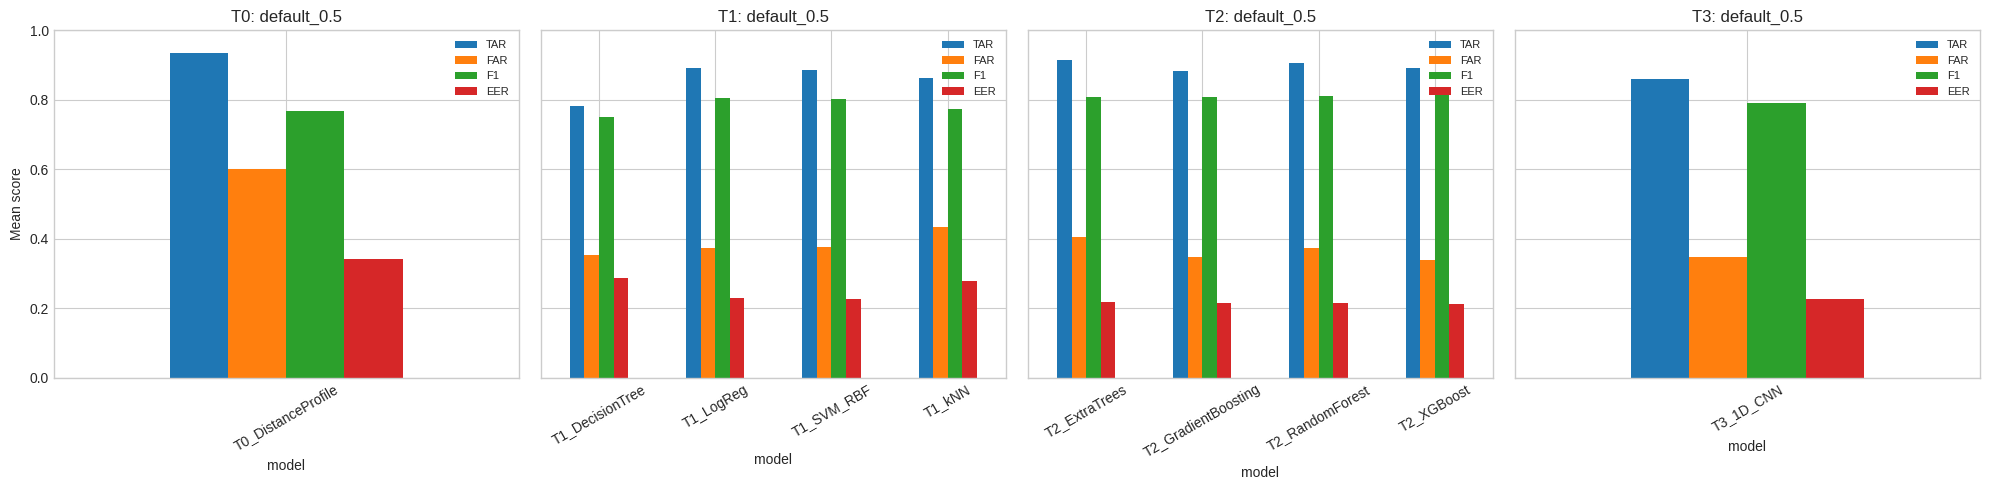

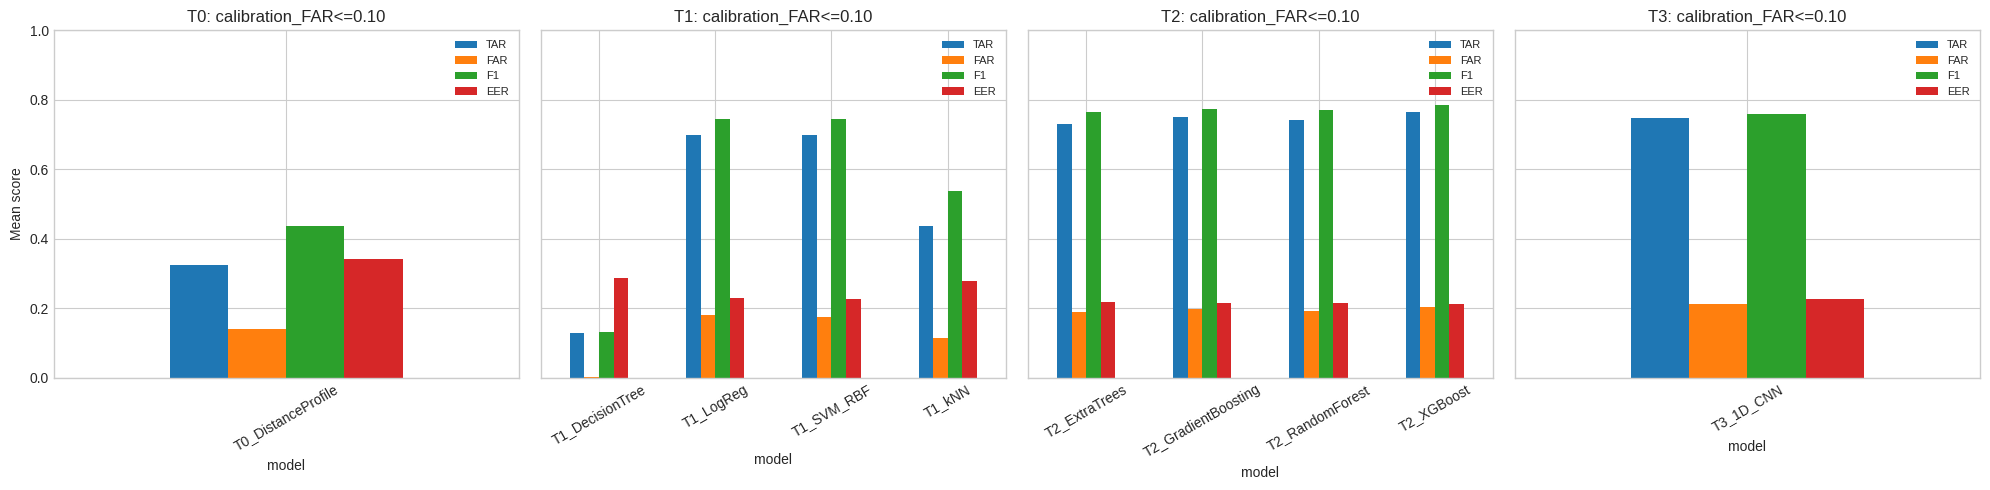

In [22]:
plt.style.use("seaborn-v0_8-whitegrid")

def plot_metric_by_tier(policy="default_0.5"):
    plot_df = (
        fair_results[fair_results["threshold_policy"] == policy]
        .groupby(["tier", "model"])[["TAR", "FAR", "F1", "EER"]]
        .mean()
        .reset_index()
    )
    tiers = [t for t in ["T0", "T1", "T2", "T3"] if t in set(plot_df["tier"])]
    fig, axes = plt.subplots(1, len(tiers), figsize=(5 * len(tiers), 5), sharey=True)
    if len(tiers) == 1:
        axes = [axes]
    for ax, tier_name in zip(axes, tiers):
        tier_plot = plot_df[plot_df["tier"] == tier_name].set_index("model")
        tier_plot[["TAR", "FAR", "F1", "EER"]].plot(kind="bar", ax=ax, rot=30)
        ax.set_title(f"{tier_name}: {policy}")
        ax.set_ylim(0, 1)
        ax.set_ylabel("Mean score")
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

plot_metric_by_tier("default_0.5")
plot_metric_by_tier(f"calibration_FAR<={LOW_FAR_TARGET:.2f}")


vulnerability_label
high      34
low       33
medium    33
Name: count, dtype: int64


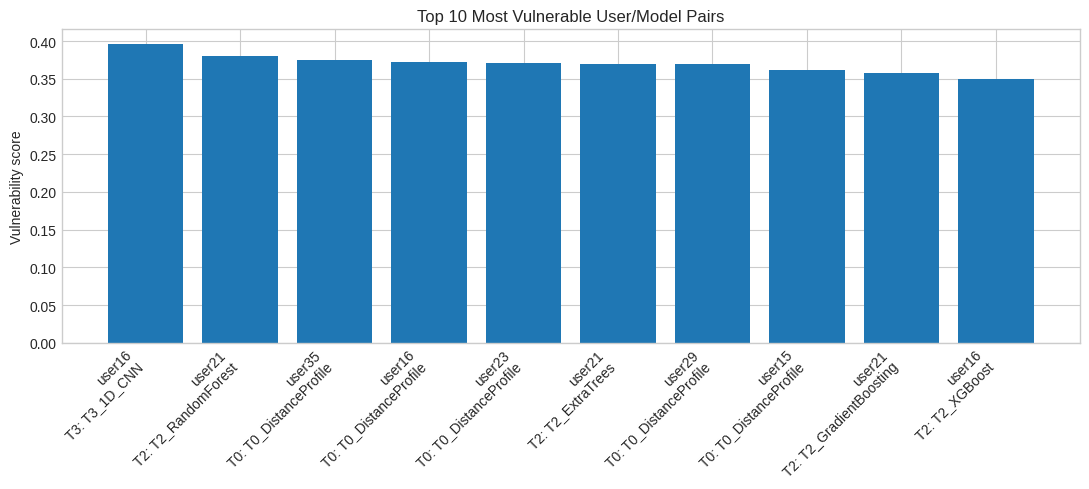

,user,tier,model,FAR,FRR,AUC,EER,vulnerability_score,vulnerability_label
29,user16,T3,T3_1D_CNN,0.346570,0.510433,0.587922,0.428419,0.395729,high
47,user21,T2,T2_RandomForest,0.406746,0.316611,0.695559,0.351738,0.379705,high
70,user35,T0,T0_DistanceProfile,0.219013,0.740467,0.583861,0.438858,0.375449,high
20,user16,T0,T0_DistanceProfile,0.220217,0.726592,0.513928,0.503243,0.372129,high
50,user23,T0,T0_DistanceProfile,0.180418,0.815205,0.497929,0.509096,0.370854,high
45,user21,T2,T2_ExtraTrees,0.378968,0.348941,0.674650,0.367913,0.369960,high
60,user29,T0,T0_DistanceProfile,0.212963,0.735435,0.663271,0.374180,0.369704,high
10,user15,T0,T0_DistanceProfile,0.243056,0.636546,0.626313,0.428300,0.361103,high
46,user21,T2,T2_GradientBoosting,0.361111,0.348941,0.697059,0.345417,0.357460,high
28,user16,T2,T2_XGBoost,0.346570,0.357945,0.713853,0.353728,0.349983,high


In [23]:
vulnerability_policy = f"calibration_FAR<={LOW_FAR_TARGET:.2f}"
vulnerability = (
    fair_results[fair_results["threshold_policy"] == vulnerability_policy]
    .groupby(["user", "tier", "model"])[["TAR", "FAR", "FRR", "F1", "AUC", "EER"]]
    .mean()
    .reset_index()
)
vulnerability["vulnerability_score"] = 0.7 * vulnerability["FAR"] + 0.3 * vulnerability["FRR"]

# Low/medium/high labels via tertiles of the observed score distribution.
# Quantile-based (rather than fixed cutoffs like 0.25/0.50) keeps the three
# classes roughly balanced regardless of how spread out the scores are,
# which matters with a small number of user/tier/model rows.
vulnerability["vulnerability_label"] = pd.qcut(
    vulnerability["vulnerability_score"], q=3, labels=["low", "medium", "high"]
)
print(vulnerability["vulnerability_label"].value_counts())

top_vulnerable = vulnerability.sort_values("vulnerability_score", ascending=False).head(10).copy()
top_vulnerable["label"] = top_vulnerable["user"] + "\n" + top_vulnerable["tier"] + ": " + top_vulnerable["model"]

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(top_vulnerable["label"], top_vulnerable["vulnerability_score"])
ax.set_title("Top 10 Most Vulnerable User/Model Pairs")
ax.set_ylabel("Vulnerability score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

top_vulnerable[["user", "tier", "model", "FAR", "FRR", "AUC", "EER", "vulnerability_score", "vulnerability_label"]]


## Per-User Vulnerability Classification (Forecasting)

Can we predict which user/tier/model combinations will be high-vulnerability *before* knowing the bypass rate, just from clean defender metrics? Features here are clean-side only (`AUC`, `EER`, `decision_threshold`) since the attacker pipeline is being developed separately.

**TODO once attacker results are ready:** merge in `bypass_rate_window` / `bypass_rate_session` (keyed by `user`) and add them to `vuln_feature_cols` below — that's the feature the feedback specifically calls out as important, and clean metrics alone are a weaker proxy for it.

In [24]:
from sklearn.model_selection import cross_val_score, cross_val_predict

# Clean-side features only for now. Add bypass_rate columns here once available.
vuln_feature_cols = ["AUC", "EER", "decision_threshold"]

vuln_lookup = (
    fair_results[fair_results["threshold_policy"] == vulnerability_policy]
    .groupby(["user", "tier", "model"])[["decision_threshold"]]
    .mean()
    .reset_index()
)
vulnerability_features = vulnerability.merge(vuln_lookup, on=["user", "tier", "model"], how="left")

X_vuln = vulnerability_features[vuln_feature_cols].fillna(0)
y_vuln = vulnerability_features["vulnerability_label"]

vuln_model = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
)

if len(vulnerability_features) >= 10 and y_vuln.nunique() > 1:
    cv_scores = cross_val_score(vuln_model, X_vuln, y_vuln, cv=3, scoring="accuracy")
    print("CV accuracy:", cv_scores, "mean=", cv_scores.mean())

    # Out-of-fold predictions: each row's prediction comes from a model that
    # never trained on that row, so this table matches what the CV accuracy
    # above is actually measuring (no in-sample inflation).
    vulnerability_features["predicted_vulnerability"] = cross_val_predict(
        vuln_model, X_vuln, y_vuln, cv=3
    )
else:
    print("Not enough rows/classes for cross-validation yet.")
    vuln_model.fit(X_vuln, y_vuln)
    vulnerability_features["predicted_vulnerability"] = vuln_model.predict(X_vuln)
    print("WARNING: predictions below are in-sample (not cross-validated) due to small sample size.")

vulnerability_features[["user", "tier", "model", "vulnerability_label", "predicted_vulnerability"]]


CV accuracy: [0.61764706 0.81818182 0.66666667] mean= 0.7008318478906714


,user,tier,model,vulnerability_label,predicted_vulnerability
0,user12,T0,T0_DistanceProfile,medium,high
1,user12,T1,T1_DecisionTree,medium,medium
2,user12,T1,T1_LogReg,low,high
3,user12,T1,T1_SVM_RBF,low,medium
4,user12,T1,T1_kNN,medium,medium
...,...,...,...,...,...
95,user9,T2,T2_ExtraTrees,low,low
96,user9,T2,T2_GradientBoosting,low,low
97,user9,T2,T2_RandomForest,low,low
98,user9,T2,T2_XGBoost,low,low


# WINDMOUSE

In [25]:
## Robustness Drop (Clean FAR vs. Attack Bypass Rate)

# REAL attack_results from the partner's WindMouse (T6) run.
# Source: Week5REU_BehavioralAuth_final_fair_T0_T1_T2_T3.ipynb,
#   run_windmouse_t6(n_attack_sessions=20, seeds=[0,1,2]), policy
#   calibration_FAR<=0.10, bypass rates averaged over the 3 seeds.
# WindMouse was scored against the T3 1D-CNN (the deployed sequence defender),
# so every row is tier="T3", model="T3_1D_CNN" to match fair_results and let
# the clean-FAR merge below resolve.

ATTACK_RESULTS_READY = True

# (bypass_rate_window, bypass_rate_session) per user, seed-averaged, FAR<=0.10.
windmouse_bypass = {
    "user15": (0.798146, 0.950000),
    "user9":  (0.699536, 0.933333),
    "user23": (0.652528, 0.700000),
    "user35": (0.237637, 0.000000),
    "user12": (0.174365, 0.000000),
    "user7":  (0.094203, 0.016667),
    "user16": (0.087179, 0.000000),
    "user29": (0.082051, 0.016667),
    "user21": (0.000000, 0.000000),
    "user20": (0.000000, 0.000000),
}

attack_results = pd.DataFrame(
    [
        {
            "user": u,
            "tier": "T3",
            "model": "T3_1D_CNN",
            "threshold_policy": vulnerability_policy,   # "calibration_FAR<=0.10"
            "attack_type": "windmouse",
            "bypass_rate_window": bw,
            "bypass_rate_session": bs,
        }
        for u, (bw, bs) in windmouse_bypass.items()
    ]
)

# Guard: every attacked user must exist in the clean T3 results, else the merge
# below silently yields NaN clean_FAR.
_clean_users = set(
    fair_results[
        (fair_results["threshold_policy"] == vulnerability_policy)
        & (fair_results["tier"] == "T3")
        & (fair_results["model"] == "T3_1D_CNN")
    ]["user"]
)
_missing = set(attack_results["user"]) - _clean_users
assert not _missing, f"attack_results users missing from clean T3 fair_results: {_missing}"
print(f"Loaded REAL WindMouse attack_results: {len(attack_results)} rows, "
      f"{attack_results['user'].nunique()} users, tier=T3/T3_1D_CNN.")

# --- Robustness drop computation (unchanged from the handoff contract) ---
clean_far = (
    fair_results[fair_results["threshold_policy"] == vulnerability_policy]
    .groupby(["user", "tier", "model"])[["FAR"]]
    .mean()
    .reset_index()
    .rename(columns={"FAR": "clean_FAR"})
)

robustness = attack_results.merge(clean_far, on=["user", "tier", "model"], how="left")
robustness["robustness_drop_window"] = robustness["bypass_rate_window"] - robustness["clean_FAR"]
robustness["robustness_drop_session"] = robustness["bypass_rate_session"] - robustness["clean_FAR"]

robustness.sort_values("robustness_drop_window", ascending=False)[
    ["user", "tier", "model", "attack_type", "clean_FAR", "bypass_rate_window",
     "robustness_drop_window", "bypass_rate_session", "robustness_drop_session"]
].head(15)

Loaded REAL WindMouse attack_results: 10 rows, 10 users, tier=T3/T3_1D_CNN.


,user,tier,model,attack_type,clean_FAR,bypass_rate_window,robustness_drop_window,bypass_rate_session,robustness_drop_session
1,user9,T3,T3_1D_CNN,windmouse,0.013382,0.699536,0.686154,0.933333,0.919951
0,user15,T3,T3_1D_CNN,windmouse,0.302350,0.798146,0.495796,0.950000,0.647650
2,user23,T3,T3_1D_CNN,windmouse,0.203520,0.652528,0.449008,0.700000,0.496480
5,user7,T3,T3_1D_CNN,windmouse,0.004049,0.094203,0.090154,0.016667,0.012618
9,user20,T3,T3_1D_CNN,windmouse,0.000000,0.000000,0.000000,0.000000,0.000000
4,user12,T3,T3_1D_CNN,windmouse,0.183829,0.174365,-0.009464,0.000000,-0.183829
3,user35,T3,T3_1D_CNN,windmouse,0.378460,0.237637,-0.140823,0.000000,-0.378460
6,user16,T3,T3_1D_CNN,windmouse,0.346570,0.087179,-0.259391,0.000000,-0.346570
7,user29,T3,T3_1D_CNN,windmouse,0.379630,0.082051,-0.297579,0.016667,-0.362963
8,user21,T3,T3_1D_CNN,windmouse,0.319444,0.000000,-0.319444,0.000000,-0.319444


# ALL TIERS

In [26]:
# ================= ALL-TIERS ATTACK BYPASS SCORING (A1 vs A2) =================
# Needs in scope: all_sessions, test_sessions,
# user_counts, get_fair_user_splits, windows_from_sessions, windows_to_tabular,
# threshold_for_target_far, predict_genuine_scores, t0_distance_profile_scores,
# build_t1_models, build_t2_models, build_cnn_fair, and the constants
# (WINDOW, LOW_FAR_TARGET, vulnerability_policy, T3_EPOCHS, T3_VALIDATION_SIZE,
# T3_BATCH_SIZE).
import glob, os
import numpy as np, pandas as pd

ENROLLED_USERS = sorted(user_counts.keys())
ATTACK_SEEDS   = [0, 1, 2]

def load_attack_sessions_by_seed(root, seeds=ATTACK_SEEDS):
    # bare read_csv (already portability-verified); extract_features only needs
    # record timestamp / x / y, which the handoff CSVs have.
    out = {}
    for s in seeds:
        paths = sorted(glob.glob(os.path.join(root, f"seed{s}", "*.csv")))
        out[s] = [pd.read_csv(p) for p in paths]
    return out

def _session_bypassed(win_scores, thr):
    # SESSION RULE (keep identical for BOTH attackers): majority of windows accepted.
    # To use a mean-evidence rule instead, swap for: return win_scores.mean() >= thr
    return float(np.mean(win_scores >= thr)) >= 0.5

def _attack_bypass(score_windows, thr, sessions):
    pooled, sess_flags = [], []
    for sess in sessions:
        Xw, _ = windows_from_sessions([sess], 1)   # per-session windows; label unused
        if len(Xw) == 0:
            continue
        sc = np.asarray(score_windows(Xw), dtype=float)
        pooled.append(sc)
        sess_flags.append(_session_bypassed(sc, thr))
    pooled = np.concatenate(pooled) if pooled else np.array([])
    win_rate  = float(np.mean(pooled >= thr)) if pooled.size else 0.0
    sess_rate = float(np.mean(sess_flags)) if sess_flags else 0.0
    return win_rate, sess_rate

def _tier_scorers(user, seed, t3_epochs):
    # Fit each tier's model(s) on this user's FIT split, calibrate FAR<=0.10 on CAL,
    # return {(tier, model): (score_windows_fn, accept_threshold)}. Mirrors the
    # run_user_t{0,1,2,3}_fair flow so attacks meet the same defenders + scaler.
    splits = get_fair_user_splits(user, seed=seed)
    scorers = {}

    # T0 distance profile
    def t0_score(Xw, _s=splits):
        return t0_distance_profile_scores(_s["X_fit_tab"], _s["y_fit"], windows_to_tabular(Xw))
    cal = t0_distance_profile_scores(splits["X_fit_tab"], splits["y_fit"], splits["X_cal_tab"])
    thr, _, _ = threshold_for_target_far(splits["y_cal"], cal, LOW_FAR_TARGET)
    scorers[("T0", "T0_DistanceProfile")] = (t0_score, thr)

    # T1 + T2 tabular sklearn
    for tier, builder in [("T1", build_t1_models), ("T2", build_t2_models)]:
        for name, model in builder(seed).items():
            model.fit(splits["X_fit_tab"], splits["y_fit"])
            cal = predict_genuine_scores(model, splits["X_cal_tab"])
            thr, _, _ = threshold_for_target_far(splits["y_cal"], cal, LOW_FAR_TARGET)
            scorers[(tier, name)] = (
                (lambda Xw, m=model: predict_genuine_scores(m, windows_to_tabular(Xw))), thr)

    # T3 1D-CNN on sequences (same train/val split + scaler as run_user_t3_fair)
    np.random.seed(seed); pyrandom.seed(seed); tf.random.set_seed(seed)
    fit_idx = np.arange(len(splits["y_fit"]))
    tr_idx, val_idx = train_test_split(fit_idx, test_size=T3_VALIDATION_SIZE,
                                       stratify=splits["y_fit"], random_state=seed)
    f = splits["X_fit_seq"].shape[2]
    scaler = StandardScaler().fit(splits["X_fit_seq"][tr_idx].reshape(-1, f))
    def _scale(seq): return scaler.transform(seq.reshape(-1, f)).reshape(seq.shape)
    cnn = build_cnn_fair(input_shape=(WINDOW, f))
    es = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
    cnn.fit(_scale(splits["X_fit_seq"][tr_idx]), splits["y_fit"][tr_idx],
            validation_data=(_scale(splits["X_fit_seq"][val_idx]), splits["y_fit"][val_idx]),
            epochs=t3_epochs, batch_size=T3_BATCH_SIZE, callbacks=[es], verbose=0)
    cal = cnn.predict(_scale(splits["X_cal_seq"]), verbose=0).ravel()
    thr, _, _ = threshold_for_target_far(splits["y_cal"], cal, LOW_FAR_TARGET)
    def t3_score(Xw, _c=cnn, _sc=_scale): return _c.predict(_sc(Xw), verbose=0).ravel()
    scorers[("T3", "T3_1D_CNN")] = (t3_score, thr)
    return scorers

def score_attack_all_tiers(attack_by_seed, attack_type, t3_epochs=T3_EPOCHS,
                           users=ENROLLED_USERS, seeds=ATTACK_SEEDS):
    # Pairs defender(seed) with that seed's attack sessions. One row per (user,tier,model,seed).
    rows = []
    for seed in seeds:
        sessions = attack_by_seed[seed]
        for user in users:
            for (tier, model_name), (score_fn, thr) in _tier_scorers(user, seed, t3_epochs).items():
                wr, sr = _attack_bypass(score_fn, thr, sessions)
                rows.append({"user": user, "tier": tier, "model": model_name,
                             "threshold_policy": vulnerability_policy, "attack_type": attack_type,
                             "seed": seed, "accept_threshold": thr,
                             "bypass_rate_window": wr, "bypass_rate_session": sr})
        print(f"[{attack_type}] seed {seed} done")
    return pd.DataFrame(rows)

In [27]:
## Abnormal / Synthetic-Looking Session Detection (Post-Authentication Layer)

from sklearn.ensemble import IsolationForest

ANOMALY_CONTAMINATION = 0.10  # rough assumed fraction of "abnormal" sessions; retune once real attack data is available

def run_user_anomaly_layer(user, seed, attack_sessions=None, contamination=ANOMALY_CONTAMINATION):
    splits = get_fair_user_splits(user, seed=seed)

    # Trained ONLY on genuine fit windows - never sees imposters or synthetic
    # attacks during training.
    genuine_fit = splits["X_fit_tab"][splits["y_fit"] == 1]
    anomaly_model = make_pipeline(
        StandardScaler(),
        IsolationForest(contamination=contamination, random_state=seed)
    )
    anomaly_model.fit(genuine_fit)

    # Gatekeeper choice: T2 RandomForest, not T3 CNN.
    # T3 has comparable mean AUC (~0.83) but noticeably higher per-user variance
    # (e.g. user16 T3 AUC = 0.59 vs. T2 ~0.70-0.85 range - see vulnerability table).
    # A stable front-door decision matters more here than squeezing out marginal
    # average gains, so T2 is used as the authentication gate; T3 is kept as a
    # tier for comparison, not as the production-candidate model.
    gatekeeper = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=seed, n_jobs=-1)
    gatekeeper.fit(splits["X_fit_tab"], splits["y_fit"])
    cal_scores = predict_genuine_scores(gatekeeper, splits["X_cal_tab"])
    accept_threshold, _, _ = threshold_for_target_far(splits["y_cal"], cal_scores, target_far=LOW_FAR_TARGET)

    # --- Real test set: genuine + real human imposter windows (already in splits) ---
    X_test_tab = splits["X_test_tab"]
    y_test = splits["y_test"].copy()
    session_type = np.where(y_test == 1, "genuine", "human_imposter")

    # --- Optional: synthetic attack windows for this user, pushed through the SAME
    #     feature extraction -> windowing -> tabular pipeline as everything else.
    #     `attack_sessions` should be a list of session dataframes shaped exactly
    #     like all_sessions/test_sessions (columns: x, y, record timestamp, user, label),
    #     where `user` = the enrolled user being targeted and label = 0. ---
    if attack_sessions:
        attack_for_user = [s for s in attack_sessions if get_user(s) == user]
        if attack_for_user:
            X_attack_seq, y_attack = windows_from_sessions(attack_for_user, label=0)
            X_attack_tab = windows_to_tabular(X_attack_seq)
            X_test_tab = pd.concat([X_test_tab, X_attack_tab], ignore_index=True)
            y_test = np.concatenate([y_test, y_attack])
            session_type = np.concatenate([session_type, np.full(len(y_attack), "synthetic_attack")])

    test_scores = predict_genuine_scores(gatekeeper, X_test_tab)
    accepted_mask = test_scores >= accept_threshold
    anomaly_pred = anomaly_model.predict(X_test_tab)  # -1 = anomalous, 1 = normal
    flagged_mask = accepted_mask & (anomaly_pred == -1)

    rows = []
    for stype in np.unique(session_type):
        type_mask = session_type == stype
        n_total = int(type_mask.sum())
        n_accepted = int((type_mask & accepted_mask).sum())
        n_flagged = int((type_mask & flagged_mask).sum())
        rows.append({
            "user": user,
            "seed": seed,
            "session_type": stype,
            "n_total": n_total,
            "n_accepted": n_accepted,
            "accept_rate": n_accepted / n_total if n_total else np.nan,
            "n_flagged_of_accepted": n_flagged,
            "flagged_rate_of_accepted": n_flagged / n_accepted if n_accepted else np.nan,
        })
    return pd.DataFrame(rows)

anomaly_rows = [
    run_user_anomaly_layer(user, seed=0, attack_sessions=None)
    for user in sorted(user_counts.keys())
]
anomaly_results = pd.concat(anomaly_rows, ignore_index=True)
anomaly_results

,user,seed,session_type,n_total,n_accepted,accept_rate,n_flagged_of_accepted,flagged_rate_of_accepted
0,user12,0,genuine,576,411,0.713542,30,0.072993
1,user12,0,human_imposter,437,76,0.173913,11,0.144737
2,user15,0,genuine,332,253,0.762048,20,0.079051
3,user15,0,human_imposter,624,172,0.275641,6,0.034884
4,user16,0,genuine,623,386,0.619583,27,0.069948
5,user16,0,human_imposter,277,85,0.306859,6,0.070588
6,user20,0,genuine,717,535,0.746165,53,0.099065
7,user20,0,human_imposter,131,1,0.007634,0,0.000000
8,user21,0,genuine,299,178,0.595318,4,0.022472
9,user21,0,human_imposter,168,53,0.315476,1,0.018868


/tmp/ipykernel_659/353719507.py:27: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, show=True)


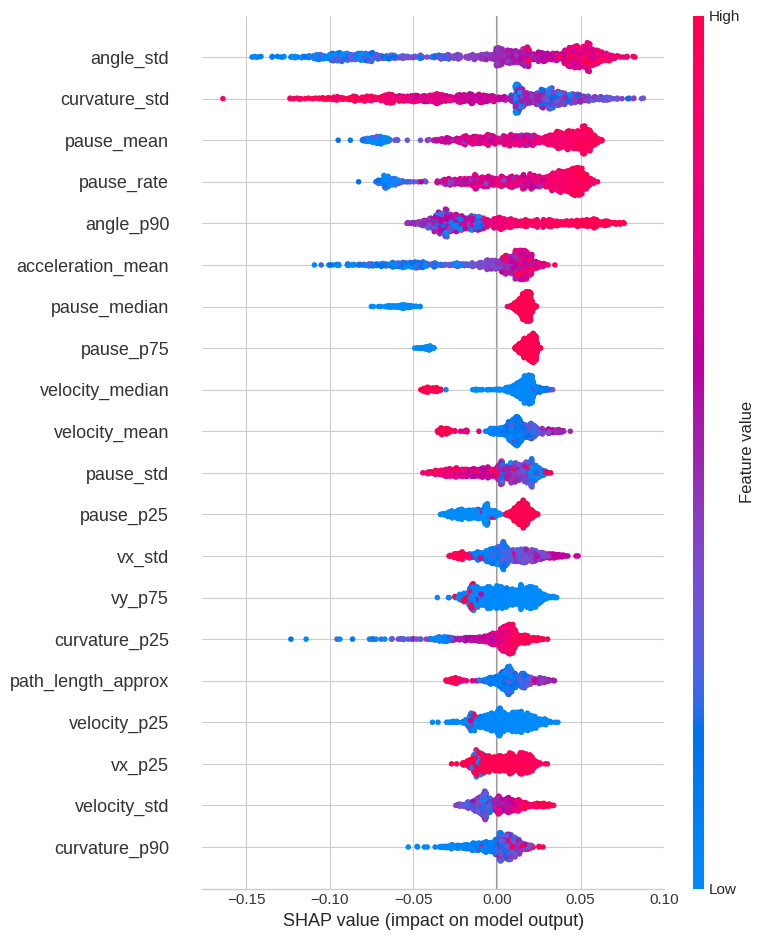

In [28]:
## SHAP Feature Importance (T2 Tree Models)

# !pip install shap --quiet   # uncomment if not already installed in your Colab session

import shap

def run_user_shap(user, seed=0, model_name="T2_RandomForest"):
    splits = get_fair_user_splits(user, seed=seed)
    models = build_t2_models(seed)
    model = models[model_name]
    model.fit(splits["X_fit_tab"], splits["y_fit"])

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(splits["X_test_tab"])

    # Handle both SHAP output formats:
    # - old: list of arrays, one per class -> take class 1 ("genuine")
    # - new: single 3D array (samples, features, classes) -> slice class 1
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]

    return shap_values, splits["X_test_tab"]

shap_values, X_shap = run_user_shap(example_user, seed=0, model_name="T2_RandomForest")
shap.summary_plot(shap_values, X_shap, show=True)

In [29]:
## Multi-User SHAP Consistency Check

def get_user_shap_importance(user, seed=0, model_name="T2_RandomForest"):
    shap_values, X_shap = run_user_shap(user, seed=seed, model_name=model_name)
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    return pd.Series(mean_abs_shap, index=X_shap.columns)

# Start with a handful of users rather than all 10 - SHAP + retraining per user adds up.
# Widen check_users to sorted(user_counts.keys()) later if this looks useful.
check_users = sorted(user_counts.keys())[:5]

importance_by_user = {}
for u in check_users:
    print(f"Computing SHAP importance for {u}...")
    importance_by_user[u] = get_user_shap_importance(u, seed=0)

importance_df = pd.DataFrame(importance_by_user)  # rows = features, columns = users
importance_df["mean_importance"] = importance_df.mean(axis=1)

# rank_std: how much a feature's rank position jumps around between users.
# Low rank_std + high mean_importance = a feature that's reliably important
# everywhere, not just for one user.
ranks = importance_df[check_users].rank(ascending=False)
importance_df["rank_std"] = ranks.std(axis=1)

top_features = importance_df.sort_values("mean_importance", ascending=False).head(15)
top_features[["mean_importance", "rank_std"] + check_users]

Computing SHAP importance for user12...
Computing SHAP importance for user15...
Computing SHAP importance for user16...
Computing SHAP importance for user20...
Computing SHAP importance for user21...


,mean_importance,rank_std,user12,user15,user16,user20,user21
pause_mean,0.029380,3.346640,0.035068,0.014947,0.032613,0.039844,0.024426
pause_rate,0.026396,3.834058,0.032761,0.014585,0.028503,0.036229,0.019902
curvature_std,0.022736,9.016651,0.038473,0.008382,0.022475,0.027347,0.017003
curvature_p25,0.022667,12.165525,0.012044,0.041578,0.012838,0.004510,0.042363
curvature_p75,0.020012,15.836666,0.003795,0.052637,0.005290,0.006180,0.032157
acceleration_std,0.019343,8.734987,0.006792,0.025783,0.024898,0.012679,0.026562
pause_median,0.017600,12.498000,0.021212,0.004021,0.017374,0.024503,0.020890
curvature_p90,0.016606,17.363755,0.009194,0.037969,0.004935,0.002931,0.028002
angle_std,0.016224,14.808781,0.046677,0.013875,0.004103,0.004165,0.012302
pause_p75,0.014990,9.782638,0.020582,0.005351,0.015152,0.024143,0.009723


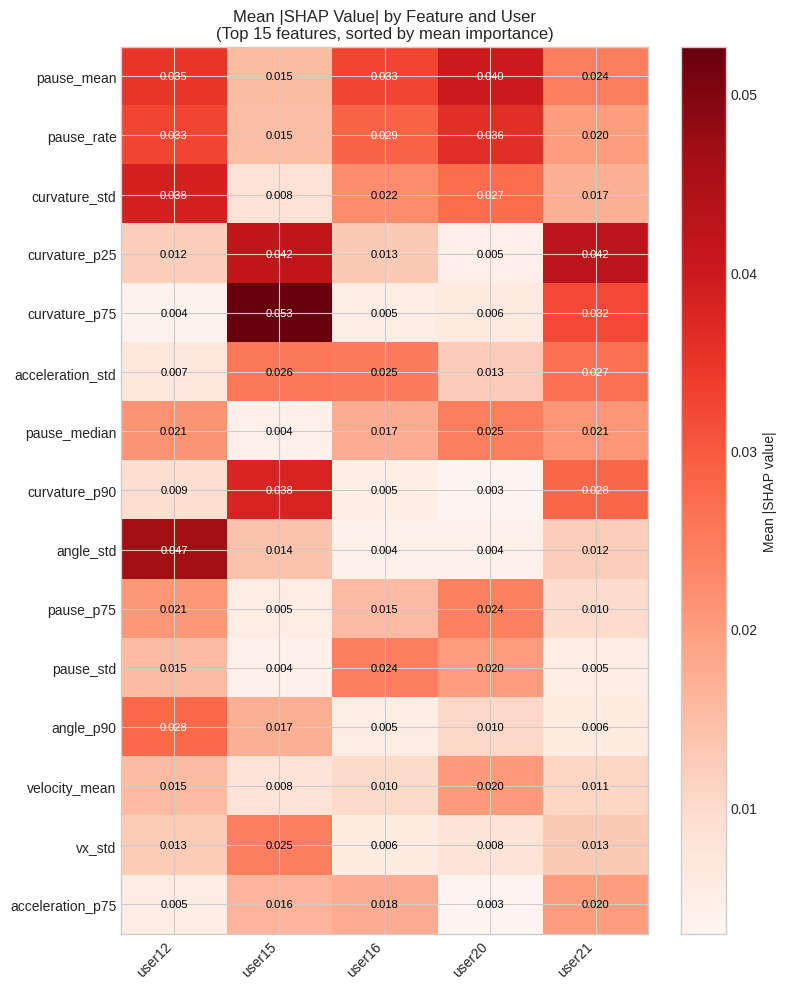

In [30]:
## SHAP Importance Heatmap Across Users

heatmap_data = top_features[check_users]  # reuse the same top 15 features/users from before

fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(heatmap_data.values, aspect="auto", cmap="Reds")

ax.set_xticks(range(len(check_users)))
ax.set_xticklabels(check_users, rotation=45, ha="right")
ax.set_yticks(range(len(heatmap_data)))
ax.set_yticklabels(heatmap_data.index)

# Annotate each cell with its value for readability.
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data.values[i, j]
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                color="white" if val > heatmap_data.values.max() * 0.5 else "black",
                fontsize=8)

ax.set_title("Mean |SHAP Value| by Feature and User\n(Top 15 features, sorted by mean importance)")
fig.colorbar(im, ax=ax, label="Mean |SHAP value|")
plt.tight_layout()
plt.show()

In [31]:
## Dr. Duan: aggregate bypass across ALL users
wm = attack_results[attack_results["attack_type"] == "windmouse"]
for col in ["bypass_rate_session", "bypass_rate_window"]:
    s = wm[col]
    print(f"{col}: mean={s.mean():.3f}  std={s.std():.3f}  median={s.median():.3f}  "
          f"min={s.min():.3f}  max={s.max():.3f}")
    print(f"  users >0.70: {(s > 0.70).sum()} / {len(s)}   at 0.00: {(s == 0).sum()} / {len(s)}")

bypass_rate_session: mean=0.262  std=0.419  median=0.008  min=0.000  max=0.950
  users >0.70: 2 / 10   at 0.00: 5 / 10
bypass_rate_window: mean=0.283  std=0.310  median=0.134  min=0.000  max=0.798
  users >0.70: 1 / 10   at 0.00: 2 / 10


# New Implementation SapiAgent

In [32]:
sapi_by_seed = load_attack_sessions_by_seed("/content/drive/MyDrive/handoff/sapiagent_sessions")

In [33]:
import glob
print(len(glob.glob("/content/drive/MyDrive/handoff/sapiagent_sessions/seed0/*.csv")))  # expect 20

20


In [34]:
# SMOKE: one user, one seed, few epochs. Expect a small table with sane 0..1 rates.
_smoke = score_attack_all_tiers({0: sapi_by_seed[0]}, "sapiagent_smoke",
                                t3_epochs=5, users=[ENROLLED_USERS[0]], seeds=[0])
display(_smoke[["tier","model","accept_threshold","bypass_rate_window","bypass_rate_session"]])

[sapiagent_smoke] seed 0 done


,tier,model,accept_threshold,bypass_rate_window,bypass_rate_session
0,T0,T0_DistanceProfile,0.692709,0.000000,0.0
1,T1,T1_LogReg,0.714436,0.104167,0.0
2,T1,T1_SVM_RBF,0.754716,0.000000,0.0
3,T1,T1_kNN,1.000000,0.137500,0.0
4,T1,T1_DecisionTree,1.000000,0.000000,0.0
5,T2,T2_RandomForest,0.680000,0.000000,0.0
6,T2,T2_ExtraTrees,0.696667,0.012500,0.0
7,T2,T2_GradientBoosting,0.690035,0.000000,0.0
8,T2,T2_XGBoost,0.737169,0.004167,0.0
9,T3,T3_1D_CNN,0.524571,0.766667,1.0


In [ ]:
# FULL run (T3 refits 10 users x 3 seeds = the slow part; keep T3_EPOCHS for final numbers)
# Note: this overwrites the WindMouse attack_results above; both are analyzed in their own cells but not combined.
sapi_rows = score_attack_all_tiers(sapi_by_seed, "sapiagent", t3_epochs=T3_EPOCHS)

attack_results = sapi_rows.copy()
attack_results.to_csv("/content/drive/MyDrive/attack_results_all_tiers.csv", index=False)
print("rows:", len(attack_results), "| tiers:", sorted(attack_results.tier.unique()))

[sapiagent] seed 0 done
[sapiagent] seed 1 done
[sapiagent] seed 2 done
rows: 300 | tiers: ['T0', 'T1', 'T2', 'T3']


In [36]:
sa = attack_results[attack_results.attack_type == "sapiagent"]

# Dr. Duan: aggregate per defender, seed-averaged per user, report spread + bimodal shape
per_user = sa.groupby(["tier","model","user"])["bypass_rate_session"].mean().reset_index()
agg = per_user.groupby(["tier","model"])["bypass_rate_session"].agg(
    mean="mean", std="std", median="median",
    n_over_0p70=lambda x: int((x > 0.70).sum()), n_at_0=lambda x: int((x == 0).sum()))
display(agg.round(3))   # T3_1D_CNN row is the direct comparison to WindMouse's 0.262

# Paradox for A2: AUC should NOT predict bypass (~0); decision threshold should (negative)
far = fair_results[fair_results.threshold_policy == vulnerability_policy]
merged = sa.merge(far[["user","tier","model","seed","AUC","decision_threshold"]],
                  on=["user","tier","model","seed"], how="left")
for x in ["AUC", "decision_threshold"]:
    for y in ["bypass_rate_session", "bypass_rate_window"]:
        print(f"corr({x}, {y}) = {merged[[x,y]].dropna().corr().iloc[0,1]:+.3f}")

mean    std  median  n_over_0p70  n_at_0
tier model                                                         
T0   T0_DistanceProfile   0.000  0.000   0.000            0      10
T1   T1_DecisionTree      0.015  0.047   0.000            0       9
     T1_LogReg            0.202  0.421   0.000            2       7
     T1_SVM_RBF           0.100  0.316   0.000            1       9
     T1_kNN               0.060  0.127   0.000            0       8
T2   T2_ExtraTrees        0.003  0.011   0.000            0       9
     T2_GradientBoosting  0.088  0.167   0.000            0       7
     T2_RandomForest      0.000  0.000   0.000            0      10
     T2_XGBoost           0.057  0.135   0.000            0       8
T3   T3_1D_CNN            0.230  0.275   0.158            1       4

corr(AUC, bypass_rate_session) = +0.010
corr(AUC, bypass_rate_window) = +0.018
corr(decision_threshold, bypass_rate_session) = -0.153
corr(decision_threshold, bypass_rate_window) = -0.172


In [37]:
sa = attack_results[attack_results.attack_type == "sapiagent"]
t3 = (sa[sa.model == "T3_1D_CNN"]
      .groupby("user")["bypass_rate_session"].mean()
      .sort_values(ascending=False))
print(t3.round(3))

user
user21    0.800
user12    0.467
user9     0.400
user35    0.317
user16    0.300
user23    0.017
user15    0.000
user20    0.000
user29    0.000
user7     0.000
Name: bypass_rate_session, dtype: float64


In [38]:
agg.to_csv("/content/drive/MyDrive/sapiagent_bypass_by_tier.csv")